In [6]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, ListedColormap
from datetime import datetime, timedelta
from scipy.stats import linregress
import rasterio
from rasterio.warp import reproject, Resampling

try:
    import pymannkendall as mk
    HAS_MK = True
    print("pymannkendall available")
except ImportError:
    HAS_MK = False
    print("pymannkendall not found — run: pip install pymannkendall")

pymannkendall available


In [7]:
snow_dir = r"C:\Users\Arnaz Dholakia\OneDrive\Arnaz Working Segment\D Drive_Legion\AKF-K\new_data\snow"
dem_dir  = r"C:\Users\Arnaz Dholakia\OneDrive\Arnaz Working Segment\D Drive_Legion\AKF-K\new_data\dem"

# Elevation zone definitions (ICIMOD standard for Central Asia)
ZONE_LABELS = {
    1: "< 1500 m",
    2: "1500–3000 m",
    3: "3000–4500 m",
    4: "> 4500 m"
}
ZONE_COLORS = {
    1: "#e6a817",   # yellow  — valley
    2: "#4caf50",   # green   — montane
    3: "#2196f3",   # blue    — sub-alpine
    4: "#9c27b0"    # purple  — alpine/nival
}

# MODIS ~500m pixel at ~41°N ≈ 0.134 km²
# Recomputed precisely below once we read the file
PIXEL_AREA_KM2 = None  # set in Cell 4

In [8]:
def parse_date(filepath):
    """
    Handles both naming conventions:
      AQUA_TERRA_8day_MOYD10A2V61_5t_3s_2002201.tif  → year=2002, doy=201
      MOD10A2_2003_001.tif                            → year=2003, doy=001
    """
    name = os.path.basename(filepath)
    # Pattern 1: ends in 7-digit YYYYDDD
    m = re.search(r'(\d{4})(\d{3})\.tif$', name)
    if m:
        year, doy = int(m.group(1)), int(m.group(2))
        return datetime(year, 1, 1) + timedelta(days=doy - 1)
    # Pattern 2: YYYY_DDD anywhere in name
    m = re.search(r'(\d{4})[_\-](\d{3})', name)
    if m:
        year, doy = int(m.group(1)), int(m.group(2))
        return datetime(year, 1, 1) + timedelta(days=doy - 1)
    return None

# Collect and sort all snow TIFs
snow_files = sorted(glob.glob(os.path.join(snow_dir, "*.tif")))
dates      = [parse_date(f) for f in snow_files]

# Drop any files where date parsing failed
valid      = [(f, d) for f, d in zip(snow_files, dates) if d is not None]
snow_files, dates = zip(*valid)
snow_files = list(snow_files)
dates      = list(dates)

years = sorted(set(d.year for d in dates))

print(f"Total files   : {len(snow_files)}")
print(f"Date range    : {dates[0].date()} → {dates[-1].date()}")
print(f"Years covered : {years[0]} – {years[-1]}")
print(f"\nFiles per year:")
for yr in years:
    n = sum(1 for d in dates if d.year == yr)
    print(f"  {yr} : {n} files")

Total files   : 941
Date range    : 2002-07-20 → 2022-12-27
Years covered : 2002 – 2022

Files per year:
  2002 : 21 files
  2003 : 46 files
  2004 : 46 files
  2005 : 46 files
  2006 : 46 files
  2007 : 46 files
  2008 : 46 files
  2009 : 46 files
  2010 : 46 files
  2011 : 46 files
  2012 : 46 files
  2013 : 46 files
  2014 : 46 files
  2015 : 46 files
  2016 : 46 files
  2017 : 46 files
  2018 : 46 files
  2019 : 46 files
  2020 : 46 files
  2021 : 46 files
  2022 : 46 files


In [9]:
with rasterio.open(snow_files[0]) as src:
    snow_shape     = (src.height, src.width)
    snow_transform = src.transform
    snow_crs       = src.crs
    snow_nodata    = src.nodata
    res_x          = abs(src.transform.a)   # degrees per pixel (longitude)
    res_y          = abs(src.transform.e)   # degrees per pixel (latitude)

# Approximate pixel area at centroid latitude (~41°N for Kyrgyzstan)
import math
lat_centre   = 41.0
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * math.cos(math.radians(lat_centre))
PIXEL_AREA_KM2 = res_x * km_per_deg_lon * res_y * km_per_deg_lat

print(f"Snow grid shape   : {snow_shape}")
print(f"Pixel resolution  : {res_x:.6f}° × {res_y:.6f}°")
print(f"Pixel area        : {PIXEL_AREA_KM2:.4f} km²")
print(f"CRS               : {snow_crs}")
print(f"NoData value      : {snow_nodata}")

Snow grid shape   : (1068, 2882)
Pixel resolution  : 0.003829° × 0.003829°
Pixel area        : 0.1363 km²
CRS               : EPSG:4326
NoData value      : 255.0


In [10]:
dem_files = glob.glob(os.path.join(dem_dir, "*.tif"))
print("DEM files found:")
for f in dem_files:
    with rasterio.open(f) as src:
        arr = src.read(1)
        nd  = src.nodata
        arr_valid = arr[arr != nd] if nd is not None else arr
        print(f"  {os.path.basename(f)}")
        print(f"    Shape  : {src.height} × {src.width}")
        print(f"    CRS    : {src.crs}")
        print(f"    Range  : {arr_valid.min()} – {arr_valid.max()}")
        print()

DEM files found:
  cl_kg_dem.tif
    Shape  : 14709 × 39709
    CRS    : EPSG:4326
    Range  : 1 – 4

  kg_dem.tif
    Shape  : 14709 × 39709
    CRS    : EPSG:4326
    Range  : 395 – 7848



In [12]:
# Cell 6 — Load Classified DEM (memory-safe)
cls_path = None
raw_path = None

for f in dem_files:
    with rasterio.open(f) as src:
        # Read a small sample (every 50th pixel) to detect if classified or raw
        arr_sample = src.read(1, out_shape=(src.height // 50, src.width // 50),
                              resampling=Resampling.nearest).astype(np.float32)
        nd = src.nodata
        if nd is not None:
            arr_sample[arr_sample == nd] = np.nan
        unique_vals = np.unique(arr_sample[~np.isnan(arr_sample)])

        if len(unique_vals) <= 10:
            cls_path = f
            print(f"Classified DEM : {os.path.basename(f)}  — classes: {unique_vals}")
        else:
            raw_path = f
            print(f"Raw elevation  : {os.path.basename(f)}  — {np.nanmin(arr_sample):.0f}–{np.nanmax(arr_sample):.0f} m")

# Load classified DEM in blocks to avoid MemoryError
print(f"\nLoading classified DEM in blocks...")
with rasterio.open(cls_path) as src:
    cls_transform = src.transform
    cls_crs       = src.crs
    cls_nodata    = src.nodata
    cls_height    = src.height
    cls_width     = src.width

    # Count zone pixels block by block (no full array in memory)
    zone_counts_orig = {z: 0 for z in [1, 2, 3, 4]}
    block_size = 1024

    for row_off in range(0, cls_height, block_size):
        row_end  = min(row_off + block_size, cls_height)
        for col_off in range(0, cls_width, block_size):
            col_end = min(col_off + block_size, cls_width)
            window  = rasterio.windows.Window(col_off, row_off,
                                              col_end - col_off,
                                              row_end - row_off)
            block = src.read(1, window=window).astype(np.float32)
            if cls_nodata is not None:
                block[block == cls_nodata] = np.nan
            for z in [1, 2, 3, 4]:
                zone_counts_orig[z] += int(np.nansum(block == z))

print("Zone pixel counts (original DEM resolution):")
for z in [1, 2, 3, 4]:
    n = zone_counts_orig[z]
    print(f"  Zone {z} ({ZONE_LABELS[z]}): {n:,} pixels  (~{n * PIXEL_AREA_KM2:,.0f} km² approx)")

Classified DEM : cl_kg_dem.tif  — classes: [1. 2. 3. 4.]
Raw elevation  : kg_dem.tif  — 400–7029 m

Loading classified DEM in blocks...
Zone pixel counts (original DEM resolution):
  Zone 1 (< 1500 m): 26,903,304 pixels  (~3,666,864 km² approx)
  Zone 2 (1500–3000 m): 73,257,199 pixels  (~9,984,804 km² approx)
  Zone 3 (3000–4500 m): 113,183,273 pixels  (~15,426,644 km² approx)
  Zone 4 (> 4500 m): 66,386,602 pixels  (~9,048,356 km² approx)


In [14]:
cls_resampled = np.empty(snow_shape, dtype=np.float32)
zone_ids = [1, 2, 3, 4]  # add this line

with rasterio.open(cls_path) as src:
    reproject(
        source        = rasterio.band(src, 1),
        destination   = cls_resampled,
        src_transform = src.transform,
        src_crs       = src.crs,
        dst_transform = snow_transform,
        dst_crs       = snow_crs,
        resampling    = Resampling.nearest
    )

# Mask nodata
cls_resampled[cls_resampled == cls_nodata] = np.nan

# Zone pixel counts on resampled grid
zone_pixels = {z: int(np.nansum(cls_resampled == z)) for z in zone_ids}
zone_area   = {z: zone_pixels[z] * PIXEL_AREA_KM2    for z in zone_ids}

print("Zone pixel counts (resampled to snow grid):")
for z in zone_ids:
    print(f"  Zone {z} ({ZONE_LABELS[z]}): {zone_pixels[z]:,} pixels  =  {zone_area[z]:,.0f} km²")

Zone pixel counts (resampled to snow grid):
  Zone 1 (< 1500 m): 141,668 pixels  =  19,309 km²
  Zone 2 (1500–3000 m): 385,502 pixels  =  52,543 km²
  Zone 3 (3000–4500 m): 595,958 pixels  =  81,228 km²
  Zone 4 (> 4500 m): 349,433 pixels  =  47,627 km²


In [30]:
# This is the core loop — reads all 941 files and computes SCA per zone
records = []

for i, (fpath, date) in enumerate(zip(snow_files, dates)):

    if i % 50 == 0:
        print(f"  Processing {i+1}/{len(snow_files)} — {date.date()}")

    with rasterio.open(fpath) as src:
        snow = src.read(1).astype(np.float32)
        nd   = src.nodata
    if nd is not None:
        snow[snow == nd] = np.nan

    m = date.month
    if   m in [11,12, 1, 2, 3]:  season = "Winter"
    elif m in [4, 5, 6]:   season = "Spring"
    elif m in [7, 8, 9]:   season = "Summer"
    else:                   season = "Autumn"

    row = {
        "date"  : date,
        "year"  : date.year,
        "month" : date.month,
        "doy"   : date.timetuple().tm_yday,
        "season": season
    }

    for z in zone_ids:
        mask        = (cls_resampled == z)
        snow_in     = snow[mask]
        valid_px    = snow_in[~np.isnan(snow_in)]
        snow_px     = np.sum(valid_px == 1)
        total_px    = len(valid_px)
        row[f"z{z}_km2"] = snow_px * PIXEL_AREA_KM2
        row[f"z{z}_pct"] = (snow_px / total_px * 100) if total_px > 0 else np.nan

    records.append(row)

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"\nDone. DataFrame shape: {df.shape}")
print(df[["date", "year", "season"] + [f"z{z}_km2" for z in zone_ids]].head(10))

  Processing 1/941 — 2002-07-20
  Processing 51/941 — 2003-08-21
  Processing 101/941 — 2004-09-21
  Processing 151/941 — 2005-10-24
  Processing 201/941 — 2006-11-25
  Processing 251/941 — 2007-12-27
  Processing 301/941 — 2009-01-25
  Processing 351/941 — 2010-02-26
  Processing 401/941 — 2011-03-30
  Processing 451/941 — 2012-04-30
  Processing 501/941 — 2013-06-02
  Processing 551/941 — 2014-07-04
  Processing 601/941 — 2015-08-05
  Processing 651/941 — 2016-09-05
  Processing 701/941 — 2017-10-08
  Processing 751/941 — 2018-11-09
  Processing 801/941 — 2019-12-11
  Processing 851/941 — 2021-01-09
  Processing 901/941 — 2022-02-10

Done. DataFrame shape: (941, 13)
        date  year  season    z1_km2      z2_km2       z3_km2        z4_km2
0 2002-07-20  2002  Summer  0.000000  166.964950  1925.889583  18750.231996
1 2002-07-28  2002  Summer  0.272596  219.848542  1560.611162  14632.808189
2 2002-08-05  2002  Summer  0.000000  124.031105   933.640739  14444.171870
3 2002-08-13  2002 

In [31]:
# Annual mean SCA per zone
annual = df.groupby("year").agg(
    **{f"z{z}_km2": (f"z{z}_km2", "mean") for z in zone_ids},
    **{f"z{z}_pct": (f"z{z}_pct", "mean") for z in zone_ids}
).reset_index()

# Seasonal mean SCA per zone per year
seasonal = df.groupby(["year", "season"]).agg(
    **{f"z{z}_km2": (f"z{z}_km2", "mean") for z in zone_ids}
).reset_index()

print("Annual means (km²):")
print(annual[["year"] + [f"z{z}_km2" for z in zone_ids]].to_string(index=False))

Annual means (km²):
 year      z1_km2       z2_km2       z3_km2       z4_km2
 2002 3157.062186  8432.025270 28390.771964 31902.150324
 2003 3218.023476 13946.524467 43264.280724 37765.234551
 2004 1836.386295 12047.298905 40102.720142 36682.809819
 2005 3105.616213 12721.434334 38132.610774 36485.909699
 2006 3654.630153 12476.776608 36738.783819 35577.599631
 2007 2829.426260  9426.778835 30760.419349 33567.365341
 2008 3642.905569 12203.703729 39162.116357 34992.798599
 2009 2557.535617 13034.374354 41693.678332 39872.930741
 2010 1964.965603 11325.559947 39966.819266 38727.557113
 2011 3561.636454 12758.741445 38256.579657 36827.389317
 2012 5183.267601 15371.868835 38476.635608 36080.411540
 2013 3211.152283 11885.593278 35655.938341 34458.421870
 2014 4345.716895 14263.058604 38851.733405 34808.594926
 2015 2566.433501 12602.461067 39505.821188 35953.239657
 2016 2899.975247 12138.751846 37929.197983 35401.378275
 2017 3214.097504 12778.569829 40105.374989 35409.295407
 2018 2699.

In [32]:
trend_results = {}

print("=" * 65)
for z in zone_ids:
    col  = f"z{z}_km2"
    y    = annual[col].values
    x    = annual["year"].values

    slope, intercept, r, p, se = linregress(x, y)
    sig  = p < 0.05

    res = {
        "slope"      : slope,
        "intercept"  : intercept,
        "r2"         : r**2,
        "p_lr"       : p,
        "significant": sig
    }

    if HAS_MK:
        mk_res = mk.original_test(y)
        res.update({
            "mk_trend"  : mk_res.trend,
            "mk_p"      : mk_res.p,
            "mk_tau"    : mk_res.Tau,
            "sen_slope" : mk_res.slope
        })

    trend_results[z] = res

    print(f"Zone {z}: {ZONE_LABELS[z]}")
    print(f"  Linear  : {slope:+.1f} km²/yr  |  p={p:.3f}  |  R²={r**2:.2f}  |  {'SIGNIFICANT' if sig else 'not significant'}")
    if HAS_MK:
        print(f"  Mann-Kendall : {mk_res.trend}  |  τ={mk_res.Tau:.3f}  |  p={mk_res.p:.3f}  |  Sen's slope={mk_res.slope:+.1f} km²/yr")
    print()

Zone 1: < 1500 m
  Linear  : -31.6 km²/yr  |  p=0.313  |  R²=0.05  |  not significant
  Mann-Kendall : no trend  |  τ=-0.210  |  p=0.194  |  Sen's slope=-40.2 km²/yr

Zone 2: 1500–3000 m
  Linear  : -0.3 km²/yr  |  p=0.996  |  R²=0.00  |  not significant
  Mann-Kendall : no trend  |  τ=-0.152  |  p=0.349  |  Sen's slope=-51.1 km²/yr

Zone 3: 3000–4500 m
  Linear  : +45.4 km²/yr  |  p=0.714  |  R²=0.01  |  not significant
  Mann-Kendall : no trend  |  τ=-0.095  |  p=0.566  |  Sen's slope=-69.2 km²/yr

Zone 4: > 4500 m
  Linear  : -13.7 km²/yr  |  p=0.829  |  R²=0.00  |  not significant
  Mann-Kendall : no trend  |  τ=-0.124  |  p=0.450  |  Sen's slope=-55.4 km²/yr



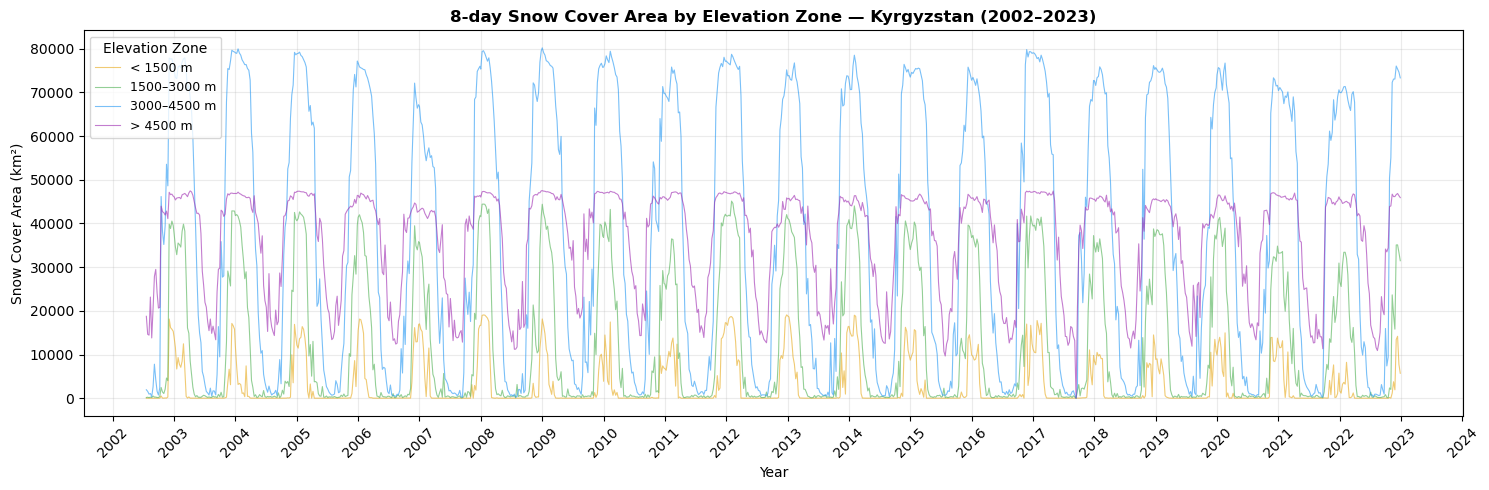

In [33]:
fig, ax = plt.subplots(figsize=(15, 5))

for z in zone_ids:
    ax.plot(df["date"], df[f"z{z}_km2"],
            lw=0.8, alpha=0.6, color=ZONE_COLORS[z], label=ZONE_LABELS[z])

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Snow Cover Area (km²)")
ax.set_title("8-day Snow Cover Area by Elevation Zone — Kyrgyzstan (2002–2023)", fontweight="bold")
ax.legend(title="Elevation Zone", fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig1_sca_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

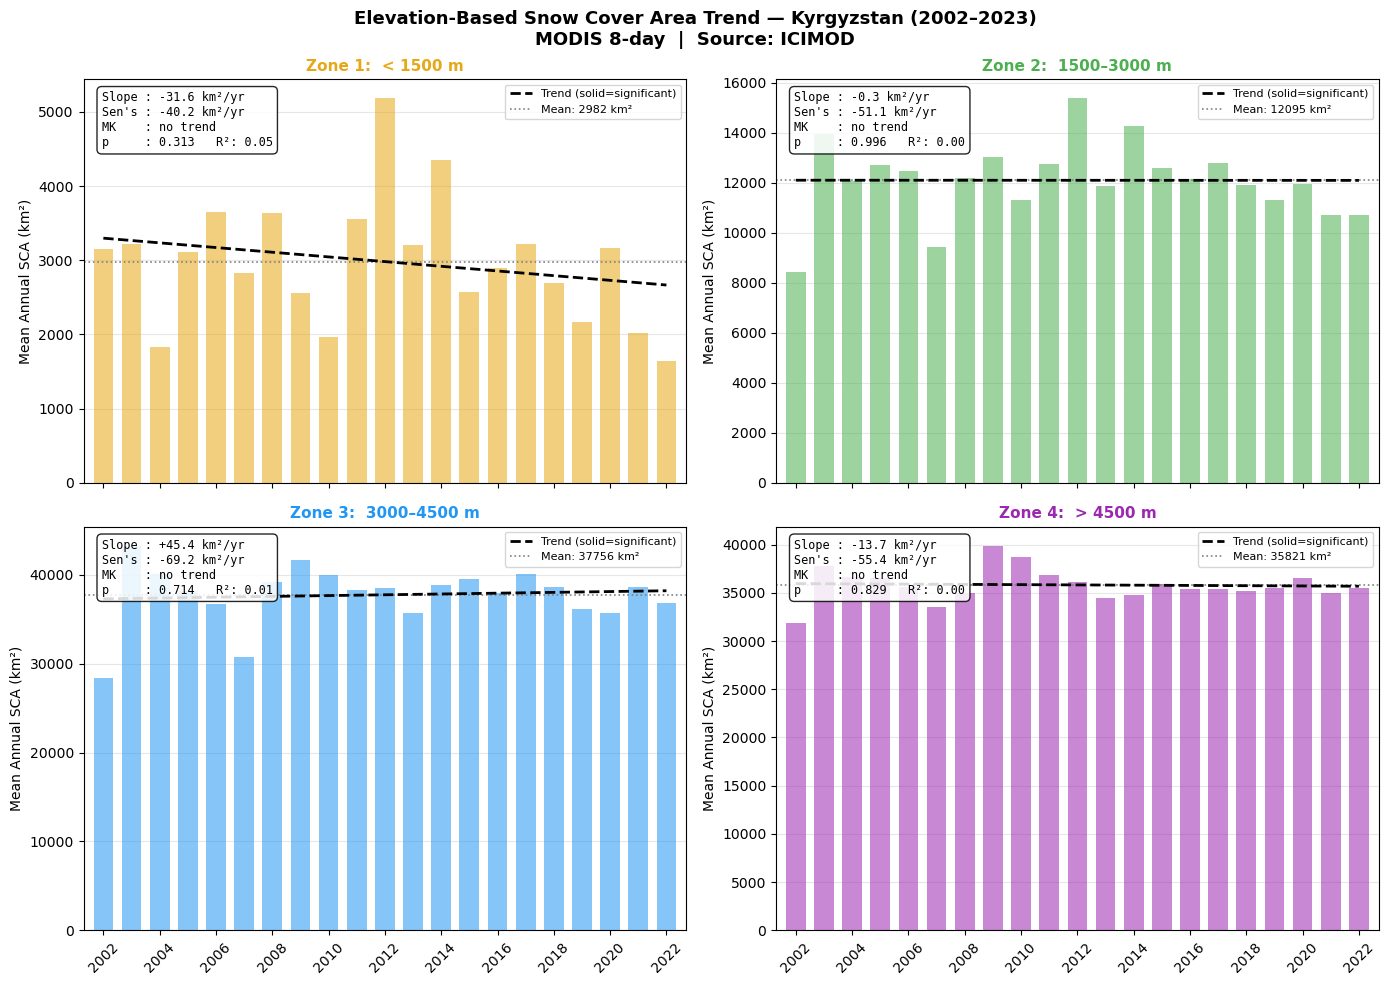

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for idx, z in enumerate(zone_ids):
    ax  = axes[idx]
    col = f"z{z}_km2"
    x   = annual["year"].values
    y   = annual[col].values
    tr  = trend_results[z]

    # Bar chart
    ax.bar(x, y, color=ZONE_COLORS[z], alpha=0.55, width=0.7, zorder=2)

    # Trend line
    y_fit = tr["intercept"] + tr["slope"] * x
    ls    = "-" if tr["significant"] else "--"
    ax.plot(x, y_fit, color="black", lw=2.0, ls=ls, zorder=3,
            label="Trend (solid=significant)")

    # Mean line
    ax.axhline(y.mean(), color="grey", lw=1.2, ls=":", zorder=2, label=f"Mean: {y.mean():.0f} km²")

    # Annotation box
    if HAS_MK:
        ann = (f"Slope : {tr['slope']:+.1f} km²/yr\n"
               f"Sen's : {tr['sen_slope']:+.1f} km²/yr\n"
               f"MK    : {tr['mk_trend']}\n"
               f"p     : {tr['p_lr']:.3f}   R²: {tr['r2']:.2f}")
    else:
        ann = (f"Slope : {tr['slope']:+.1f} km²/yr\n"
               f"p     : {tr['p_lr']:.3f}\n"
               f"R²    : {tr['r2']:.2f}")

    ax.text(0.03, 0.97, ann, transform=ax.transAxes,
            va="top", ha="left", fontsize=8.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))

    ax.set_title(f"Zone {z}:  {ZONE_LABELS[z]}", fontsize=11,
                 fontweight="bold", color=ZONE_COLORS[z])
    ax.set_ylabel("Mean Annual SCA (km²)")
    ax.set_xlim(x.min() - 0.7, x.max() + 0.7)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    "Elevation-Based Snow Cover Area Trend — Kyrgyzstan (2002–2023)\n"
    "MODIS 8-day  |  Source: ICIMOD",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig2_annual_trend_4panels.png", dpi=150, bbox_inches="tight")
plt.show()

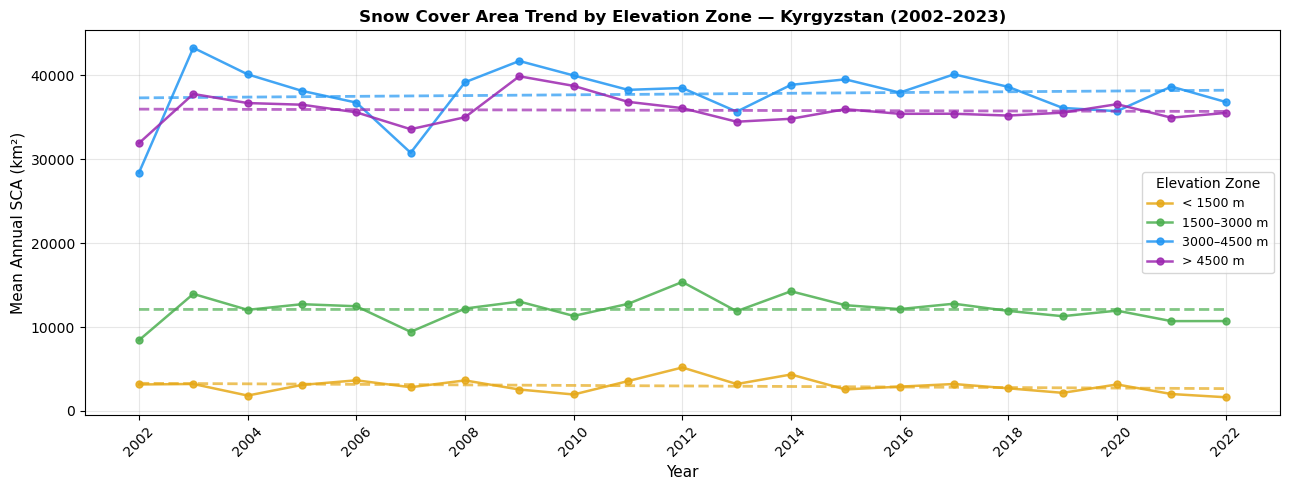

In [35]:
fig, ax = plt.subplots(figsize=(13, 5))

for z in zone_ids:
    col   = f"z{z}_km2"
    x     = annual["year"].values
    y     = annual[col].values
    tr    = trend_results[z]
    y_fit = tr["intercept"] + tr["slope"] * x

    ax.plot(x, y, marker="o", ms=5, lw=1.8,
            color=ZONE_COLORS[z], label=ZONE_LABELS[z], alpha=0.85)
    ax.plot(x, y_fit, lw=2.0, ls="--", color=ZONE_COLORS[z], alpha=0.7)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean Annual SCA (km²)", fontsize=11)
ax.set_title("Snow Cover Area Trend by Elevation Zone — Kyrgyzstan (2002–2023)",
             fontsize=12, fontweight="bold")
ax.legend(title="Elevation Zone", fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_all_zones_trend.png", dpi=150, bbox_inches="tight")
plt.show()

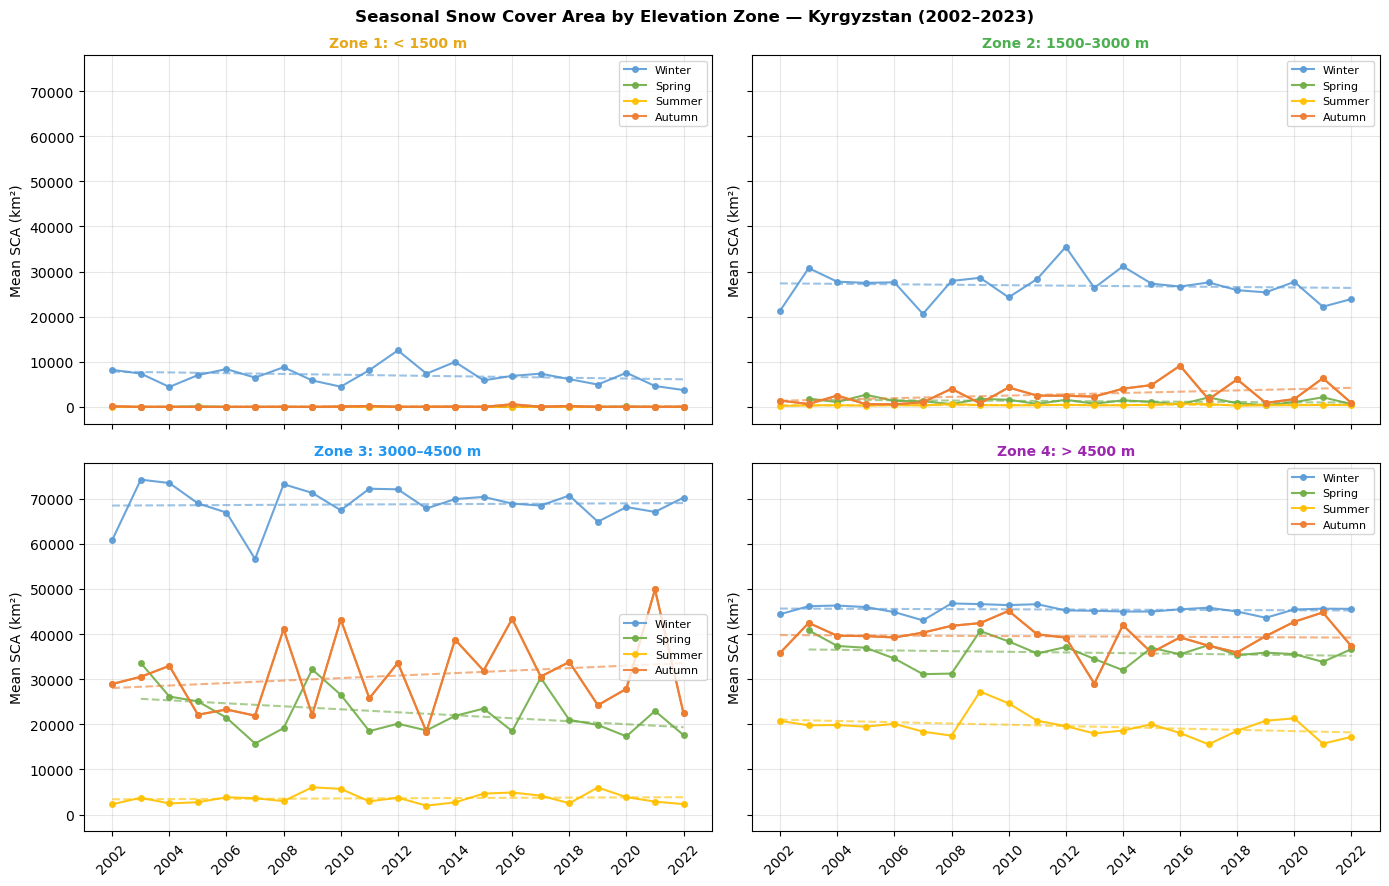

In [36]:
seasons       = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {"Winter": "#5b9bd5", "Spring": "#70ad47",
                 "Summer": "#ffc000", "Autumn": "#ed7d31"}

season_labels = {
    "Winter" : "Winter (Nov–Mar)",
    "Spring" : "Spring/Melt (Apr–Jun)",
    "Summer" : "Summer (Jul–Sep)",
    "Autumn" : "Autumn (Oct)"
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)  # sharey=True added
axes = axes.ravel()

for idx, z in enumerate(zone_ids):
    ax = axes[idx]
    for season in seasons:
        sub = seasonal[seasonal["season"] == season].sort_values("year")
        if sub.empty:
            continue
        ax.plot(sub["year"], sub[f"z{z}_km2"],
                marker="o", ms=4, lw=1.5,
                color=season_colors[season], label=season, alpha=0.9)
        # Seasonal trend line
        xs = sub["year"].values
        ys = sub[f"z{z}_km2"].values
        if len(xs) > 2:
            sl, ic, *_ = linregress(xs, ys)
            ax.plot(xs, ic + sl * xs, lw=1.5, ls="--",
                    color=season_colors[season], alpha=0.6)

    ax.set_title(f"Zone {z}: {ZONE_LABELS[z]}", fontsize=10,
                 fontweight="bold", color=ZONE_COLORS[z])
    ax.set_ylabel("Mean SCA (km²)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.plot(sub["year"], sub[f"z{z}_km2"],
        marker="o", ms=4, lw=1.5,
        color=season_colors[season],
        label=season_labels[season],   # descriptive label
        alpha=0.9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Seasonal Snow Cover Area by Elevation Zone — Kyrgyzstan (2002–2023)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_seasonal_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()

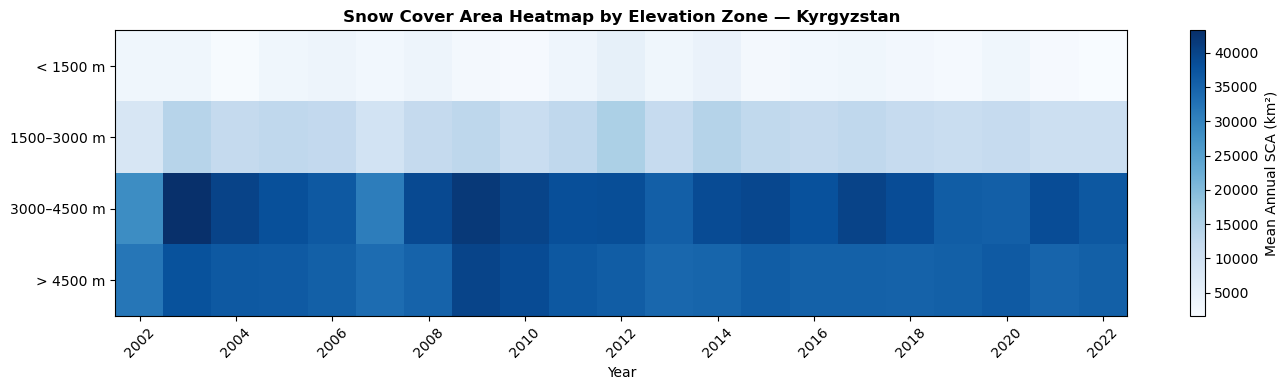

In [37]:
# Matrix: rows = zones, cols = years
matrix = np.array([[annual[f"z{z}_km2"].values] for z in zone_ids]).squeeze()

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(matrix, aspect="auto", cmap="Blues",
               extent=[years[0] - 0.5, years[-1] + 0.5, 4.5, 0.5])
plt.colorbar(im, ax=ax, label="Mean Annual SCA (km²)")
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels([ZONE_LABELS[z] for z in zone_ids])
ax.set_xlabel("Year")
ax.set_title("Snow Cover Area Heatmap by Elevation Zone — Kyrgyzstan", fontweight="bold")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Processing 941 files one at a time...
  1/941 — 2002-07-20
  101/941 — 2004-09-21
  201/941 — 2006-11-25
  301/941 — 2009-01-25
  401/941 — 2011-03-30
  501/941 — 2013-06-02
  601/941 — 2015-08-05
  701/941 — 2017-10-08
  801/941 — 2019-12-11
  901/941 — 2022-02-10
Done.


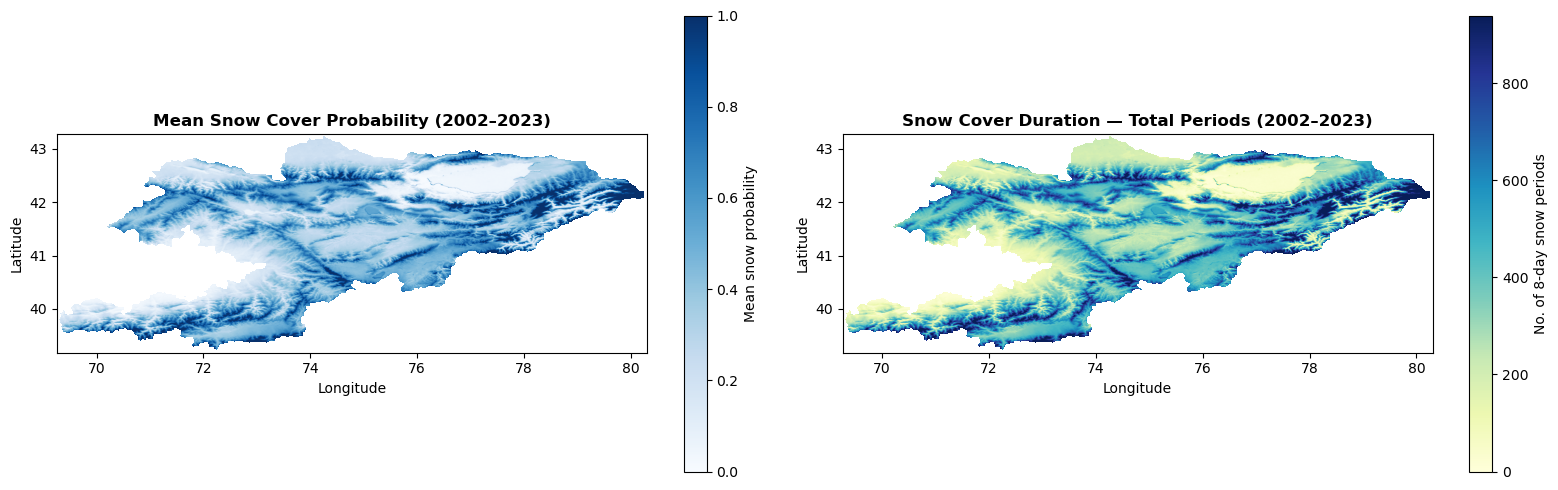

In [38]:
# Cell 16 — Mean Snow Cover & SCD Maps (memory-safe, no full stack loaded)

mean_snow = np.zeros(snow_shape, dtype=np.float64)
scd        = np.zeros(snow_shape, dtype=np.float32)
valid_count = np.zeros(snow_shape, dtype=np.float32)  # tracks non-nan pixels per location

print(f"Processing {len(snow_files)} files one at a time...")

for i, f in enumerate(snow_files):
    with rasterio.open(f) as src:
        band = src.read(1).astype(np.float32)
        nd   = src.nodata

    if nd is not None:
        valid_mask = (band != nd)
    else:
        valid_mask = ~np.isnan(band)

    # Accumulate sum for mean (only valid pixels)
    mean_snow[valid_mask] += band[valid_mask]
    valid_count[valid_mask] += 1

    # Snow cover duration: count pixels where value == 1
    scd[band == 1] += 1

    if i % 100 == 0:
        print(f"  {i+1}/{len(snow_files)} — {dates[i].date()}")

# Finalise mean (avoid divide by zero)
with np.errstate(invalid='ignore'):
    mean_snow = np.where(valid_count > 0, mean_snow / valid_count, np.nan)

# Mask pixels never observed
scd[valid_count == 0] = np.nan

print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [69.26, 80.30, 39.18, 43.27]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(mean_snow, cmap="Blues", vmin=0, vmax=1, extent=extent)
plt.colorbar(im0, ax=axes[0], label="Mean snow probability")
axes[0].set_title("Mean Snow Cover Probability (2002–2023)", fontweight="bold")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

im1 = axes[1].imshow(scd, cmap="YlGnBu", extent=extent)
plt.colorbar(im1, ax=axes[1], label="No. of 8-day snow periods")
axes[1].set_title("Snow Cover Duration — Total Periods (2002–2023)", fontweight="bold")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("fig6_scd_maps.png", dpi=150, bbox_inches="tight")
plt.show()

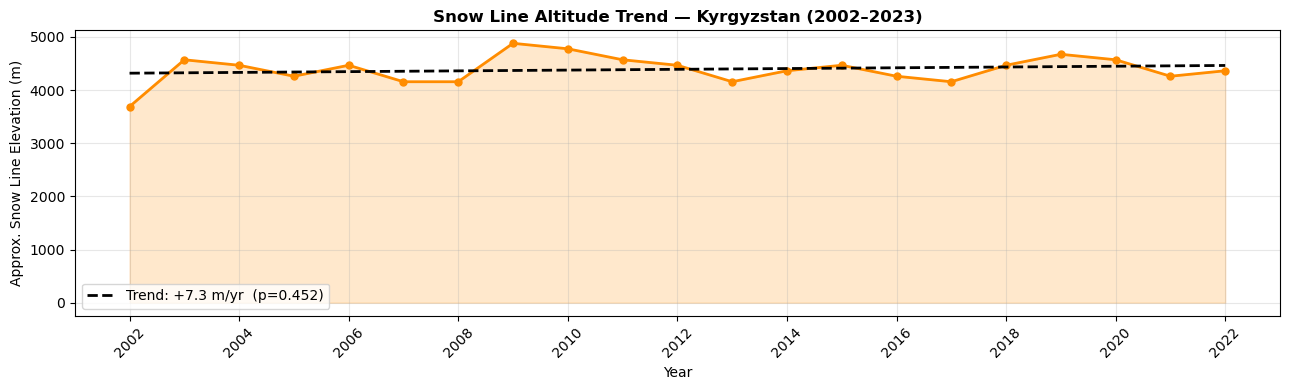

In [39]:
# Uses the per-zone SCA fractions already computed in df
# Proxy snow line: highest zone with >50% snow cover fraction

def get_snow_line_zone(row):
    for z in [4, 3, 2, 1]:
        if row[f"z{z}_pct"] >= 50:
            return z
    return 1

df["snow_line_zone"] = df.apply(get_snow_line_zone, axis=1)

# Map zone to approximate mid-elevation
zone_mid_elev = {1: 750, 2: 2250, 3: 3750, 4: 5500}
df["snow_line_elev"] = df["snow_line_zone"].map(zone_mid_elev)

annual_sle = df.groupby("year")["snow_line_elev"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(annual_sle.index, annual_sle.values,
        marker="o", ms=5, lw=2, color="darkorange")
ax.fill_between(annual_sle.index, annual_sle.values, alpha=0.2, color="darkorange")

sl, ic, r, p, _ = linregress(annual_sle.index, annual_sle.values)
ax.plot(annual_sle.index, ic + sl * annual_sle.index,
        lw=2, ls="--", color="black",
        label=f"Trend: {sl:+.1f} m/yr  (p={p:.3f})")

ax.set_xlabel("Year"); ax.set_ylabel("Approx. Snow Line Elevation (m)")
ax.set_title("Snow Line Altitude Trend — Kyrgyzstan (2002–2023)", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig7_snowline_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
rows = []
for z in zone_ids:
    col = f"z{z}_km2"
    tr  = trend_results[z]
    row = {
        "Zone"              : f"Zone {z}",
        "Elevation"         : ZONE_LABELS[z],
        "Total Area (km²)"  : f"{zone_area[z]:,.0f}",
        "Mean SCA (km²)"    : f"{annual[col].mean():,.0f}",
        "Min SCA (km²)"     : f"{annual[col].min():,.0f}",
        "Max SCA (km²)"     : f"{annual[col].max():,.0f}",
        "Mean SCA (%)"      : f"{annual[f'z{z}_pct'].mean():.1f}",
        "Trend (km²/yr)"    : f"{tr['slope']:+.1f}",
        "p-value"           : f"{tr['p_lr']:.3f}",
        "R²"                : f"{tr['r2']:.2f}",
        "Significant?"      : "Yes" if tr["significant"] else "No",
    }
    if HAS_MK:
        row["MK Trend"]     = tr["mk_trend"]
        row["Sen's Slope"]  = f"{tr['sen_slope']:+.1f}"
        row["MK p-value"]   = f"{tr['mk_p']:.3f}"
    rows.append(row)

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv("kyrgyzstan_sca_trend_summary.csv", index=False)
print("\nSaved: kyrgyzstan_sca_trend_summary.csv")

# Save full time series
df.to_csv("kyrgyzstan_sca_8day_timeseries.csv", index=False)
print("Saved: kyrgyzstan_sca_8day_timeseries.csv")

annual.to_csv("kyrgyzstan_sca_annual.csv", index=False)
print("Saved: kyrgyzstan_sca_annual.csv")

  Zone   Elevation Total Area (km²) Mean SCA (km²) Min SCA (km²) Max SCA (km²) Mean SCA (%) Trend (km²/yr) p-value   R² Significant? MK Trend Sen's Slope MK p-value
Zone 1    < 1500 m           19,309          2,982         1,637         5,183         15.5          -31.6   0.313 0.05           No no trend       -40.2      0.194
Zone 2 1500–3000 m           52,543         12,095         8,432        15,372         23.0           -0.3   0.996 0.00           No no trend       -51.1      0.349
Zone 3 3000–4500 m           81,228         37,756        28,391        43,264         46.5          +45.4   0.714 0.01           No no trend       -69.2      0.566
Zone 4    > 4500 m           47,627         35,821        31,902        39,873         75.3          -13.7   0.829 0.00           No no trend       -55.4      0.450

Saved: kyrgyzstan_sca_trend_summary.csv
Saved: kyrgyzstan_sca_8day_timeseries.csv
Saved: kyrgyzstan_sca_annual.csv
